# Solución Taller 4: Multicolinealidad, Ridge, Lasso y selección de variables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import make_pipeline

In [2]:
data = pd.read_csv("data/imcv_modelo_limpio.csv")
data.head()

,IMCV,Ingresos,Salud,Trabajo,Capital
0,32.06,0.780000,2.550000,0.510000,3.310000
1,32.88,0.960000,2.620000,0.520000,3.680000
2,33.27,1.100000,2.650000,0.570000,3.830000
3,32.82,1.121182,2.569105,0.552032,3.739863
4,33.53,1.039000,3.041000,0.485000,3.667000


## 1. Modelo e indicios de multicolinealidad

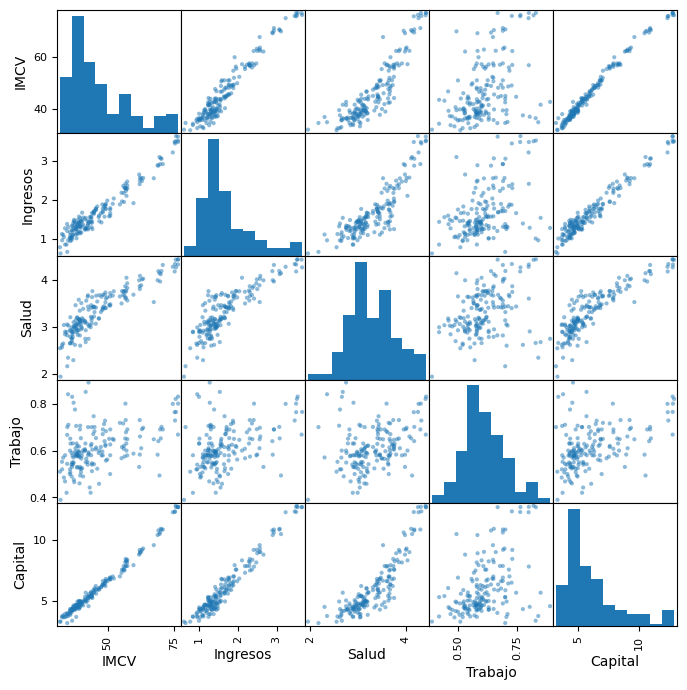

In [3]:
# Gráfico de dispersión por pares
pd.plotting.scatter_matrix(data, figsize=(8, 8))
plt.show()

In [4]:
modelo = smf.ols("IMCV ~ Ingresos + Salud + Trabajo + Capital", data=data).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   IMCV   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2814.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          3.20e-149
Time:                        22:31:17   Log-Likelihood:                -289.42
No. Observations:                 168   AIC:                             588.8
Df Residuals:                     163   BIC:                             604.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.5446      1.331      8.671      0.0

In [5]:
predictores = ["Ingresos", "Salud", "Trabajo", "Capital"]
X_pred = data[predictores]

# Matriz de correlación
print(X_pred.corr())

          Ingresos     Salud   Trabajo   Capital
Ingresos  1.000000  0.866074  0.428869  0.977313
Salud     0.866074  1.000000  0.317970  0.877605
Trabajo   0.428869  0.317970  1.000000  0.440083
Capital   0.977313  0.877605  0.440083  1.000000


## 2. Número de condición e índices de condición

In [6]:
# Factores de inflación de varianza
Xc = sm.add_constant(X_pred)
vif = pd.Series(
    [variance_inflation_factor(Xc.values, j)
     for j in range(Xc.shape[1])],
    index=Xc.columns, name="VIF"
).drop("const")
print(vif)

Ingresos    22.445411
Salud        4.494270
Trabajo      1.272229
Capital     24.986091
Name: VIF, dtype: float64


In [7]:
# Valores propios e índices de condición
Xd = Xc.to_numpy(dtype=float)
Xu = Xd / np.sqrt((Xd ** 2).sum(axis=0))
valores_propios = np.linalg.eigvalsh(Xu.T @ Xu)[::-1]
indices = np.sqrt(valores_propios[0] / valores_propios)
print(pd.Series(indices, name="Índice de condición"))

0     1.000000
1     6.522796
2    19.110100
3    39.274361
4    44.632972
Name: Índice de condición, dtype: float64


El mayor índice de condición es la raíz del número de condición, $\sqrt{\kappa} = \sqrt{\lambda_{\max}/\lambda_{\min}}$.

## 3. Regresión Ridge

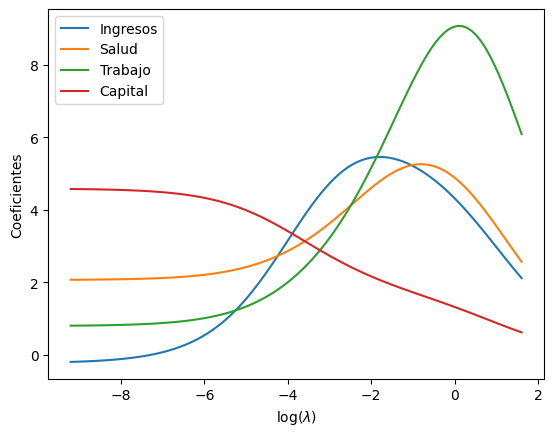

In [8]:
X = data[predictores]
y = data["IMCV"]
lambdas = np.logspace(np.log10(5), -4, 100)

# Trayectorias de los coeficientes Ridge
escala = StandardScaler()
X_std = escala.fit_transform(X)
coef_ridge = []
for lam in lambdas:
    ajuste = Ridge(alpha=len(y) * lam).fit(X_std, y)
    coef_ridge.append(ajuste.coef_ / escala.scale_)
coef_ridge = np.asarray(coef_ridge)
plt.plot(np.log(lambdas), coef_ridge)
plt.legend(predictores)
plt.xlabel(r"$\log(\lambda)$")
plt.ylabel("Coeficientes")
plt.show()

In [9]:
# Validación cruzada de tres particiones
cv = KFold(n_splits=3, shuffle=True, random_state=50)
modelo_ridge = make_pipeline(StandardScaler(), Ridge())

# En sklearn: alpha = n * lambda para Ridge
alphas = len(y) * lambdas
ridgecv = GridSearchCV(
    modelo_ridge,
    {"ridge__alpha": alphas},
    cv=cv,
    scoring="neg_mean_squared_error"
)
ridgecv.fit(X, y)

# Lambda óptimo
lambdaridge = ridgecv.best_params_["ridge__alpha"] / len(y)
print(lambdaridge)

0.001377666961405946


In [10]:
# Coeficientes estimados en la escala original
mejor = ridgecv.best_estimator_
escala = mejor.named_steps["standardscaler"]
ajuste = mejor.named_steps["ridge"]
intercepto = ajuste.intercept_ - np.sum(
    ajuste.coef_ * escala.mean_ / escala.scale_
)
coeficientes_ridge = pd.concat([
    pd.Series({"Intercepto": intercepto}),
    pd.Series(ajuste.coef_ / escala.scale_, index=X.columns)
])
print(coeficientes_ridge)

Intercepto    11.347859
Ingresos       0.224038
Salud          2.149445
Trabajo        0.922626
Capital        4.437360
dtype: float64


In [11]:
# Comparación con mínimos cuadrados
print(modelo.params)

Intercept    11.544604
Ingresos     -0.225244
Salud         2.067361
Trabajo       0.798521
Capital       4.586124
dtype: float64


## 4. Regresión Lasso

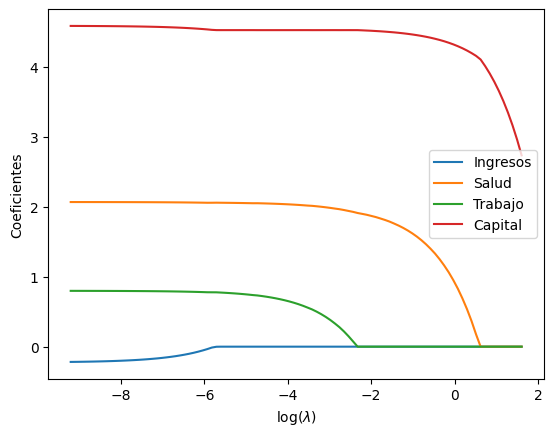

In [12]:
# Trayectorias de los coeficientes Lasso
escala = StandardScaler()
X_std = escala.fit_transform(X)
coef_lasso = []
for lam in lambdas:
    ajuste = Lasso(alpha=lam, max_iter=100000).fit(X_std, y)
    coef_lasso.append(ajuste.coef_ / escala.scale_)
coef_lasso = np.asarray(coef_lasso)
plt.plot(np.log(lambdas), coef_lasso)
plt.legend(predictores)
plt.xlabel(r"$\log(\lambda)$")
plt.ylabel("Coeficientes")
plt.show()

In [13]:
# Validación cruzada de tres particiones
cv = KFold(n_splits=3, shuffle=True, random_state=50)
modelo_lasso = make_pipeline(
    StandardScaler(), Lasso(max_iter=100000)
)

lassocv = GridSearchCV(
    modelo_lasso,
    {"lasso__alpha": lambdas},
    cv=cv,
    scoring="neg_mean_squared_error"
)
lassocv.fit(X, y)

# Lambda óptimo
lambda_lasso = lassocv.best_params_["lasso__alpha"]
print(lambda_lasso)

0.15139481898145613


Intercepto    12.826904
Ingresos       0.000000
Salud          1.852143
Trabajo        0.000000
Capital        4.511175
dtype: float64


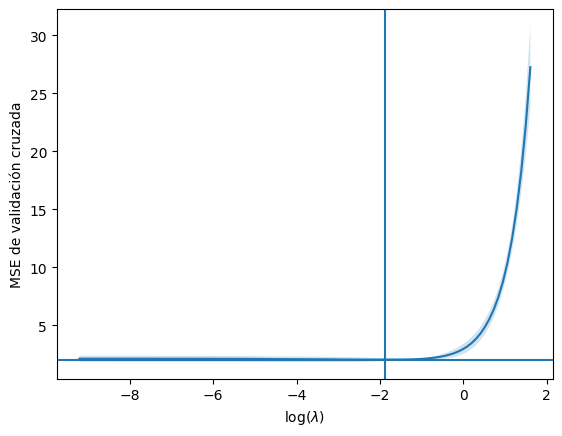

In [14]:
# Coeficientes estimados en la escala original
mejor = lassocv.best_estimator_
escala = mejor.named_steps["standardscaler"]
ajuste = mejor.named_steps["lasso"]
intercepto = ajuste.intercept_ - np.sum(
    ajuste.coef_ * escala.mean_ / escala.scale_
)
coeficientes_lasso = pd.concat([
    pd.Series({"Intercepto": intercepto}),
    pd.Series(ajuste.coef_ / escala.scale_, index=X.columns)
])
print(coeficientes_lasso)

# Gráfico del error cuadrático medio de validación cruzada
mse = -lassocv.cv_results_["mean_test_score"]
desv = lassocv.cv_results_["std_test_score"]
plt.plot(np.log(lambdas), mse)
plt.fill_between(np.log(lambdas), mse - desv, mse + desv,
                 alpha=0.2)
plt.axhline(mse.min())
plt.axvline(np.log(lambda_lasso))
plt.xlabel(r"$\log(\lambda)$")
plt.ylabel("MSE de validación cruzada")
plt.show()

In [15]:
# Coeficientes distintos de cero (sin contar el intercepto)
print((coeficientes_lasso.iloc[1:] != 0).sum())

2


## 5. Todas las regresiones posibles

In [16]:
# Funciones equivalentes a las de functions.R
from functions import (
    myAllRegTable, myR2_criterion, myAdj_R2_criterion, myCp_criterion
)

# Todas las regresiones posibles: 2^4 - 1 = 15 submodelos
myAllRegTable(modelo)

,k,R_sq,adj_R_sq,SSE,Cp,Variables_in_model
1,1,0.984,0.984,346.027,18.856,Capital
2,1,0.940,0.940,1293.539,519.565,Ingresos
3,1,0.793,0.791,4480.609,2203.758,Salud
4,1,0.190,0.185,17507.257,9087.633,Trabajo
5,2,0.986,0.986,309.306,1.452,Salud Capital
6,2,0.984,0.984,346.007,20.846,Trabajo Capital
7,2,0.984,0.984,346.016,20.850,Ingresos Capital
8,2,0.950,0.950,1072.509,404.763,Ingresos Salud
9,2,0.941,0.940,1283.091,516.044,Ingresos Trabajo
10,2,0.819,0.816,3920.752,1909.904,Salud Trabajo


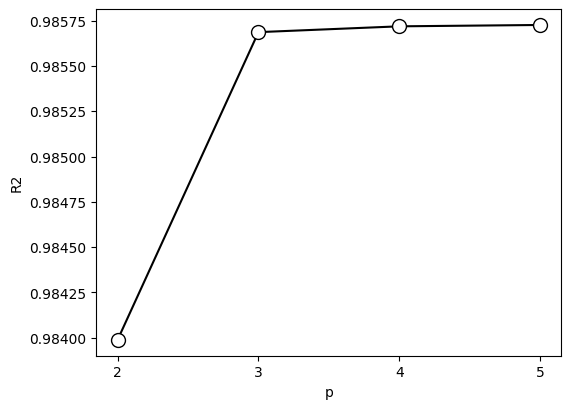

Models are Indexed in rows
 k  p        R2             Variables.in.model
 1  2 0.9839873                        Capital
 2  3 0.9856865                  Salud Capital
 3  4 0.9857186          Salud Trabajo Capital
 4  5 0.9857261 Ingresos Salud Trabajo Capital


In [17]:
myR2_criterion(modelo)       # Criterio R2

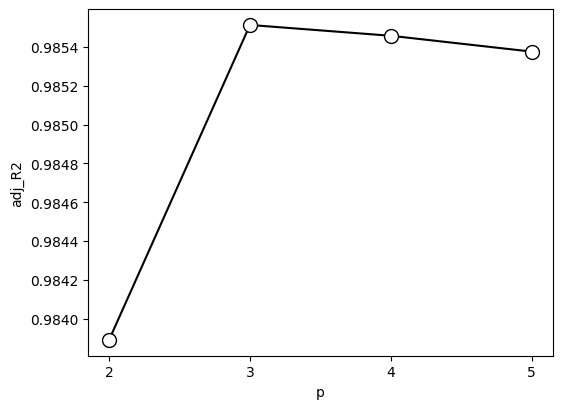

Models are Indexed in rows
 k  p     adjR2             Variables.in.model
 1  2 0.9838908                        Capital
 2  3 0.9855130                  Salud Capital
 3  4 0.9854574          Salud Trabajo Capital
 4  5 0.9853758 Ingresos Salud Trabajo Capital


In [18]:
myAdj_R2_criterion(modelo)   # Criterio R2 ajustado

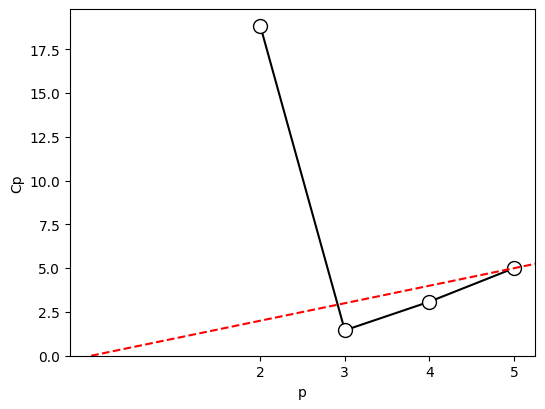

Models are Indexed in rows
 k  p        Cp             Variables.in.model
 1  2 18.856263                        Capital
 2  3  1.451564                  Salud Capital
 3  4  3.085228          Salud Trabajo Capital
 4  5  5.000000 Ingresos Salud Trabajo Capital


In [19]:
myCp_criterion(modelo)       # Criterio Cp

In [20]:
# Criterio PRESS
residual_press = modelo.resid / (1 - modelo.get_influence().hat_matrix_diag)
estadistica_press = np.sum(residual_press ** 2)
estadistica_press

np.float64(337.7990752792266)

In [21]:
# Mejor modelo: Salud + Capital (las mismas variables que conserva Lasso)
modelo_final = smf.ols("IMCV ~ Salud + Capital", data=data).fit()
print(modelo_final.summary())

Xf = sm.add_constant(data[["Salud", "Capital"]])
print(pd.Series([variance_inflation_factor(Xf.values, j) for j in range(1, 3)],
                index=["Salud", "Capital"], name="VIF"))

                            OLS Regression Results                            
Dep. Variable:                   IMCV   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     5681.
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          7.06e-153
Time:                        22:31:19   Log-Likelihood:                -289.65
No. Observations:                 168   AIC:                             585.3
Df Residuals:                     165   BIC:                             594.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     12.0727      1.036     11.652      0.0

Salud      4.351442
Capital    4.351442
Name: VIF, dtype: float64
